# Session 13: Exploratory Grade Analysis
This notebook creates a histogram of the final grade variable `G3`.

**Main output:** `figures/grade_distribution.png`

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Update the path if needed
file_path = "../data/raw/student-mat.csv"

df = pd.read_csv(file_path, sep=";")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [2]:
# Verify column G3
if "G3" in df.columns:
    print("G3 column exists. Ready to plot.")
else:
    raise ValueError("The column 'G3' was not found. Check the separator.")

# Display final grade summary
print("\nSummary of final grade G3:")
print(df["G3"].describe())
print("\nNumber of students with G3 = 0:", (df["G3"] == 0).sum())
print("Percentage of students with G3 = 0:", round((df["G3"] == 0).mean() * 100, 2), "%")

G3 column exists. Ready to plot.

Summary of final grade G3:
count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

Number of students with G3 = 0: 38
Percentage of students with G3 = 0: 9.62 %


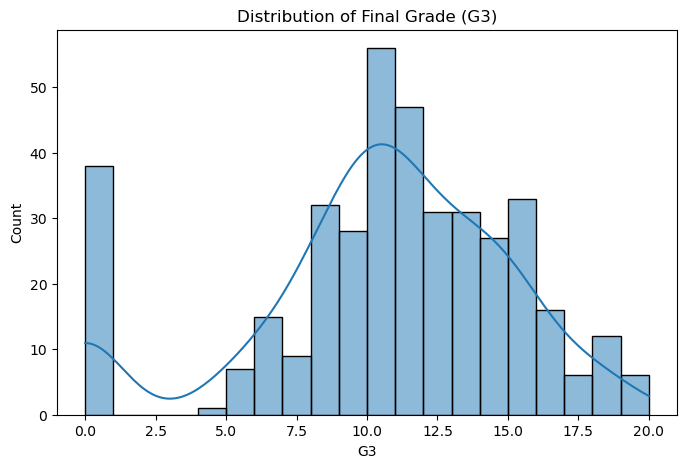

Figure saved to: ../figures/grade_distribution.png


In [3]:
# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(df["G3"], bins=20, kde=True)
plt.title("Distribution of Final Grade (G3)")
plt.xlabel("G3")
plt.ylabel("Count")

# Save the figure
plt.savefig("../figures/grade_distribution.png", bbox_inches="tight", dpi=300)
plt.show()

print("Figure saved to: ../figures/grade_distribution.png")

## Prompt-Engineered Explanation Task
**Role:** Act as an EDA assistant.  
**Task:** Interpret a final-grade histogram for an education dataset.  
**Requirements:** 1. Describe the shape of the distribution.  
2. Note whether there is a spike at zero.  
3. Discuss implications for the pass/fail threshold.  

### Summary
The G3 histogram shows how final grades are distributed across the student population, providing vital context before any machine learning modeling. It helps determine whether we should treat student performance prediction as a regression task, a classification task, or both.

### Interpretation
The overall distribution shows that most student grades are concentrated around the middle of the scale (representing moderate performance), tapering off at the very low and very high ends. However, there is a distinct, visible spike at G3 = 0. This zero-grade cluster likely represents administrative outcomes—such as course withdrawals, chronic absenteeism, or students who missed the final exam—rather than normal academic performance.

### Recommendation
If the research team defines "passing" as G3 >= 10, any student below this threshold is labeled as failing. Because the zero-grade group is likely structurally different from students who finished the class with a low grade (e.g., a 9), we must document whether we keep them in the failure class, remove them, or analyze them separately. This decision directly impacts our class balance, model accuracy, and the recall of our risk predictions.

## Reflection Question
**Question:** What might a cluster of zero final grades represent in a real school?

**Answer:**
In a real school setting, a zero grade rarely means a student completed all coursework and earned zero points. Instead, it typically indicates non-completion, class withdrawal, zero attendance, or administrative placeholders for missing exam records. 

For machine learning, this is crucial: if we train a model on these zero-grade students without distinguishing them, the model might accidentally learn predictors of "course drop-out" rather than "poor academic comprehension."

Rows used in this analysis: 395

Number of students in each study-time group:
studytime
1    105
2    198
3     65
4     27
Name: count, dtype: int64

Mean final grade by study-time group:
studytime
1    10.05
2    10.17
3    11.40
4    11.26
Name: G3, dtype: float64


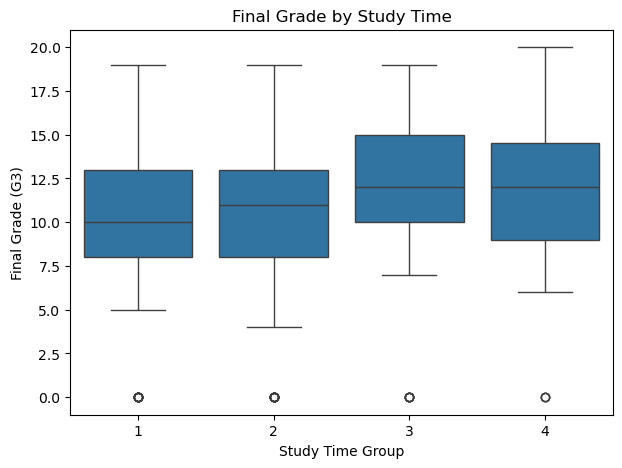


Saved figure: ../figures/studytime_vs_grade.png


In [4]:
# Session 14 Study Time and Performance Analysis (Google Colab)
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Confirm df is loaded
try:
    df
except NameError:
    raise NameError("df is not loaded. Run the data-loading cell first.")

# Ensure numeric values and drop missing data
df["studytime"] = pd.to_numeric(df["studytime"], errors="coerce")
df["G3"] = pd.to_numeric(df["G3"], errors="coerce")
plot_df = df.dropna(subset=["studytime", "G3"]).copy()
plot_df["studytime"] = plot_df["studytime"].astype(int)

# Print basic dataset counts
print("Rows used in this analysis:", len(plot_df))
print("\nNumber of students in each study-time group:")
print(plot_df["studytime"].value_counts().sort_index())

# Compute mean final grade by study-time group
print("\nMean final grade by study-time group:")
mean_grades = plot_df.groupby("studytime")["G3"].mean().round(2)
print(mean_grades)

# Create the boxplot
plt.figure(figsize=(7, 5))
sns.boxplot(x="studytime", y="G3", data=plot_df)
plt.title("Final Grade by Study Time")
plt.xlabel("Study Time Group")
plt.ylabel("Final Grade (G3)")

# Save the figure locally in Colab
plt.savefig("../figures/studytime_vs_grade.png", bbox_inches="tight", dpi=300)
plt.show()

print("\nSaved figure: ../figures/studytime_vs_grade.png")

## Session 14 Finding: Study Time and Final Grade
The figure `studytime_vs_grade.png` compares final grade `G3` across the four `studytime` groups. 

The boxplot and mean-grade comparison suggest a positive association between study time and academic outcomes, as students in higher study-time groups generally achieve higher averages than those in the lowest group. However, the trend is not perfectly monotonic, and significant distribution overlap exists between the groups. This exploratory plot shows correlation, not causation, as confounding variables such as motivation, absences, and prior grades are not controlled.